Matched rows: 61881


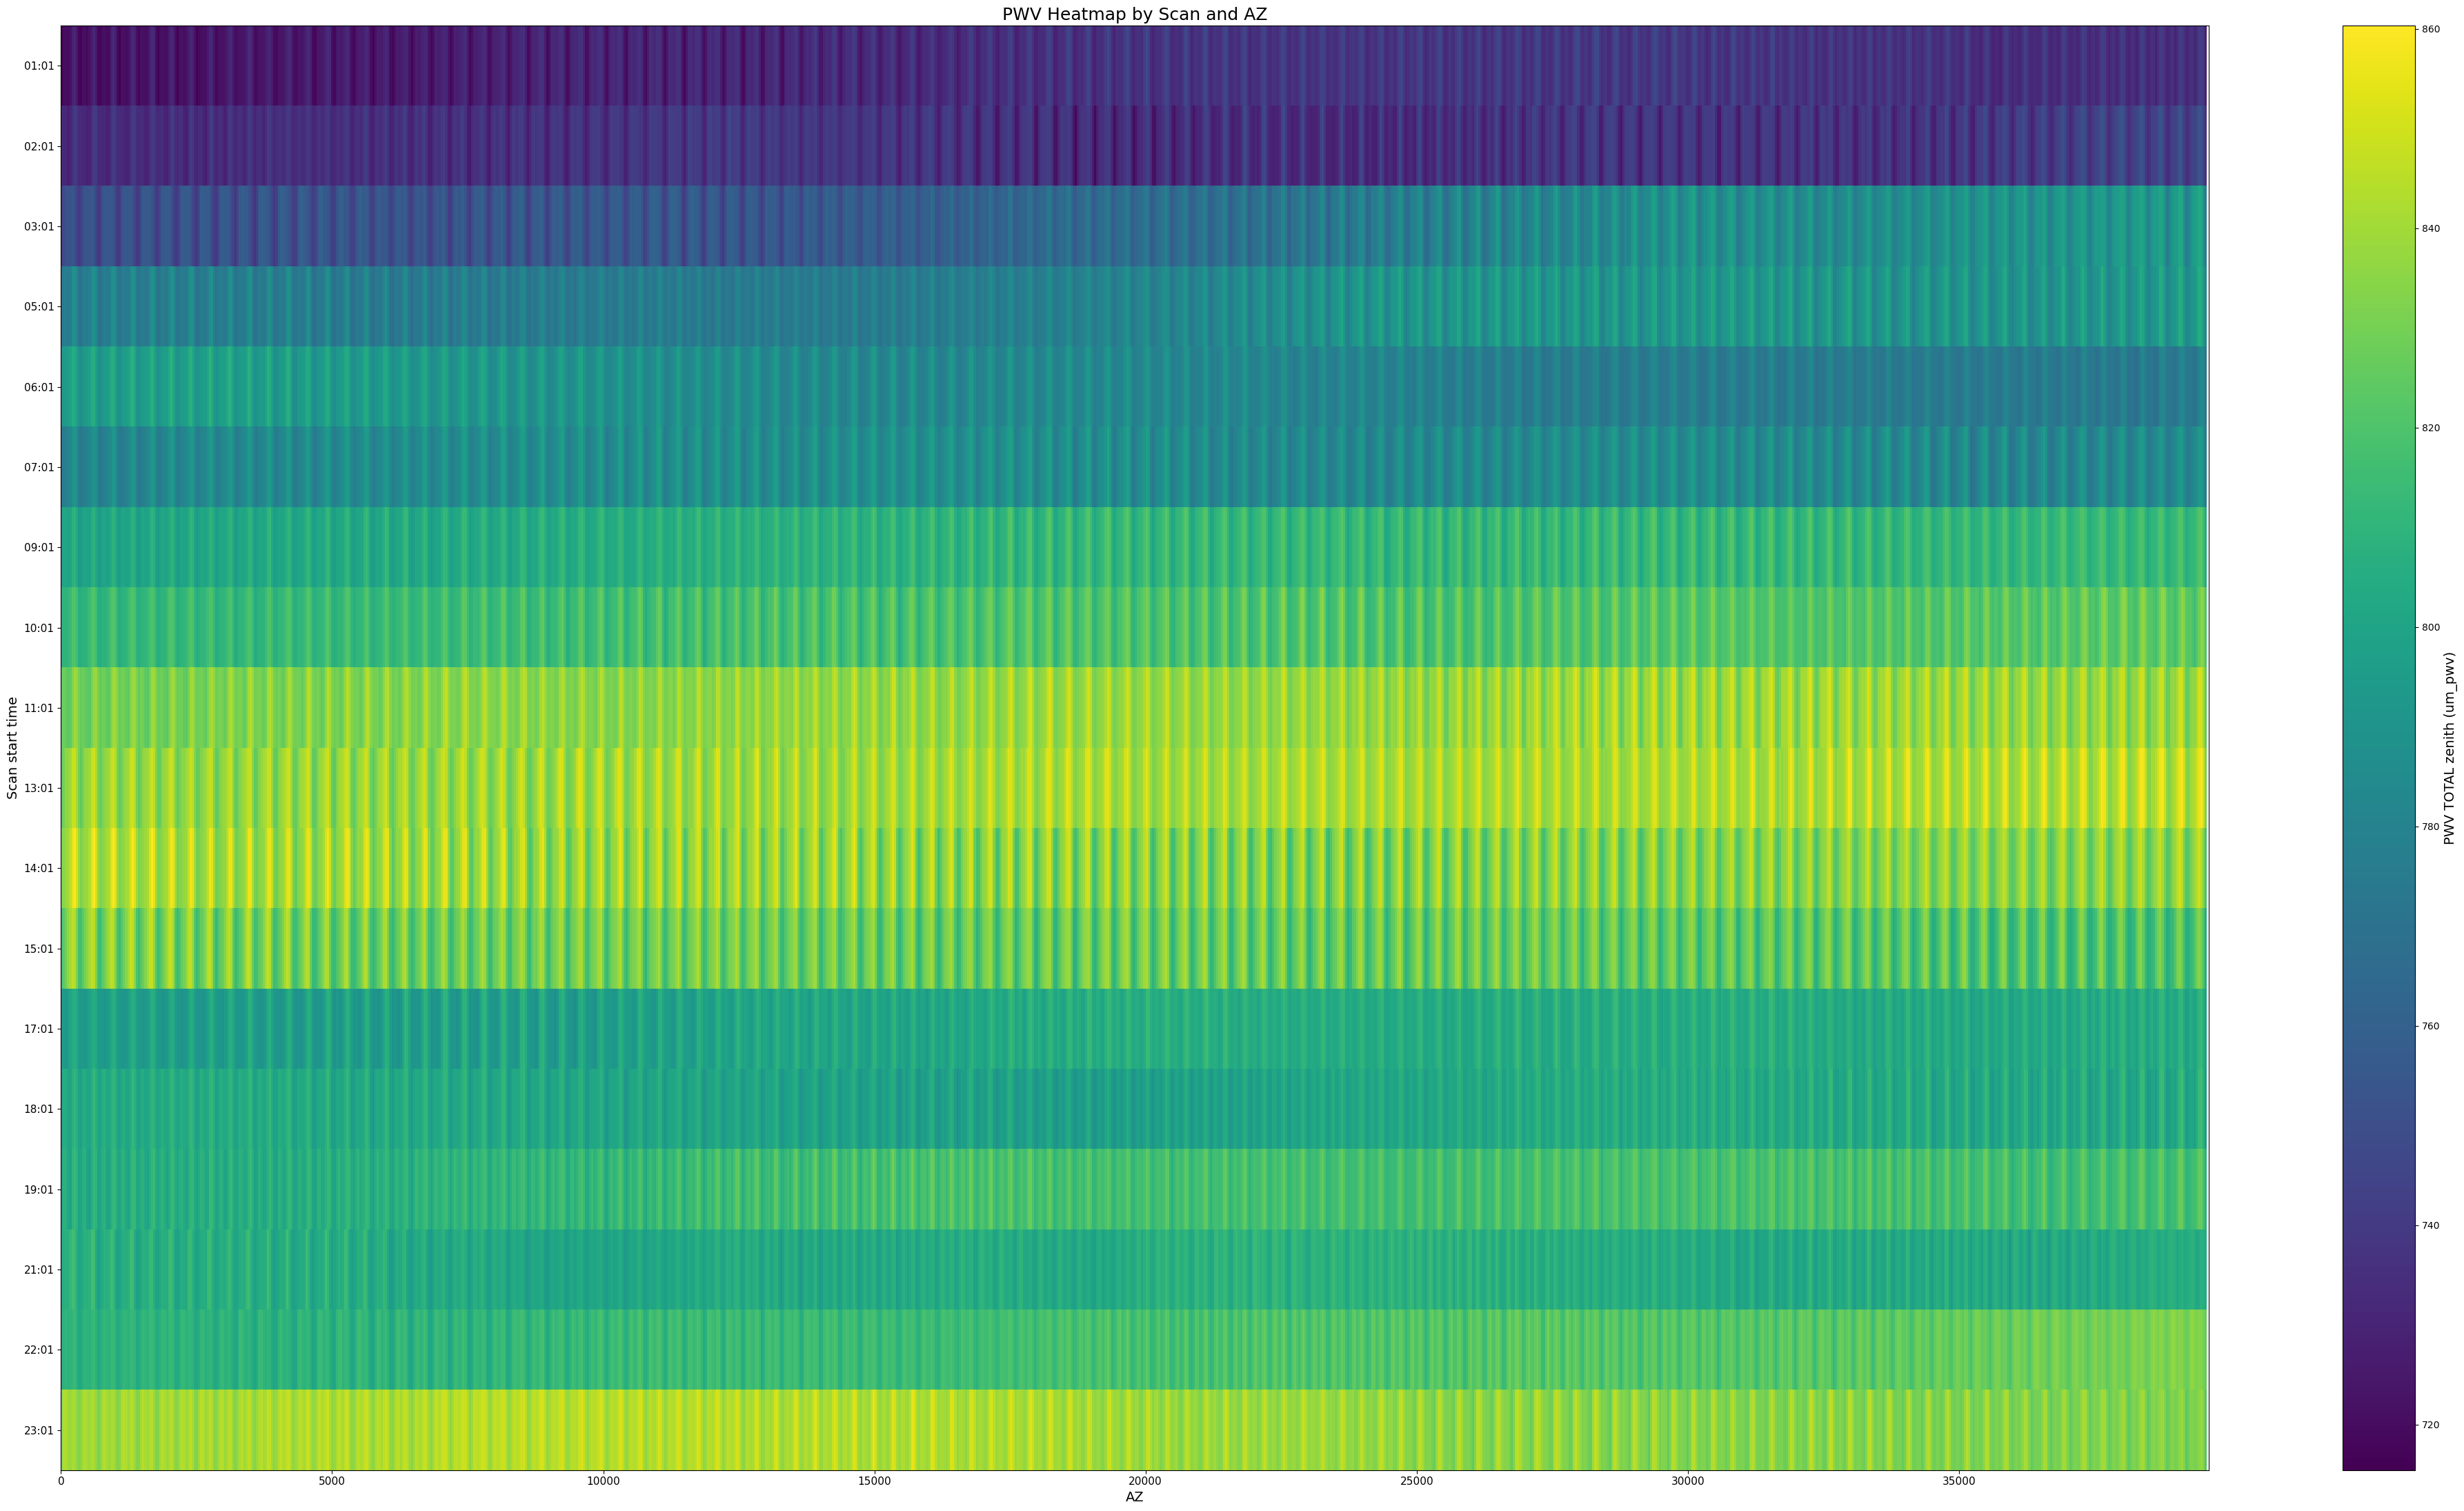

In [30]:
# better GPT ver?

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
import sys

# -----------------------------
# 1. Read PWV files
# -----------------------------
files = sorted(glob.glob('2602/0210Sec/time_pwv_2602_*.csv'))

pwv_list = []

for file in files:
    df = pd.read_csv(
        file,
        dtype={
            'DATE(YYYYMMDD)': str,
            'START TIME(HHMMSS.Microsec)': str,
            'PWV TOTAL zenith': str,
            'PWV TOTAL line-of-sight': str
        }
    )

    df['TIME'] = pd.to_datetime(
        df['DATE(YYYYMMDD)'] + ' ' + df['START TIME(HHMMSS.Microsec)'],
        format='%Y%m%d %H%M%S.%f',
        errors='coerce'
    )

    df['PWV TOTAL zenith'] = pd.to_numeric(
        df['PWV TOTAL zenith'].str.replace(' um_pwv', '', regex=False),
        errors='coerce'
    )

    df = df[['TIME', 'PWV TOTAL zenith']].dropna()
    pwv_list.append(df)

pwv_df = pd.concat(pwv_list, ignore_index=True)
pwv_df = pwv_df.sort_values('TIME').drop_duplicates(subset='TIME')

# -----------------------------
# 2. Read AZ file
# -----------------------------
showAngle_df = pd.read_csv('2602/showAngle2602.csv')
showAngle_df['Time'] = pd.to_datetime(showAngle_df['Time'], errors='coerce')
showAngle_df = showAngle_df[['Time', 'AZ']].dropna().sort_values('Time')

# -----------------------------
# 3. Match PWV to AZ by nearest time
# -----------------------------
merged = pd.merge_asof(
    pwv_df.sort_values('TIME'),
    showAngle_df.sort_values('Time'),
    left_on='TIME',
    right_on='Time',
    direction='nearest',
    tolerance=pd.Timedelta('1s')
)

merged = merged.dropna(subset=['AZ']).copy()

print("Matched rows:", len(merged))

# -----------------------------
# 4. Split into scans
#    New scan starts when AZ drops
# -----------------------------
merged['scan_id'] = (merged['AZ'].diff().fillna(0) < 0).cumsum()
"""
use df.diff() find when AZ drop
.fillna(0) will let no change be zero
<0 and .cumsum will give the scan # by add drop as add 1
For example:
    AZ =      [500, 1000, 100, 600, 100, 700]
    will give [0,   0,    1,   0,    1,   0]
so,scan_id =  [0,   0,    1,   1,    2,   2]
"""

# scan start time and duration
scan_info = merged.groupby('scan_id').agg(
    start_time=('TIME', 'min'),
    end_time=('TIME', 'max'),
    n_points=('TIME', 'size')
)

"""print(scan_info):
                        start_time                   end_time  n_points
scan_id                                                                
0       2026-02-10 01:01:36.217888 2026-02-10 01:56:35.880915      3438
1       2026-02-10 02:01:35.639150 2026-02-10 02:56:35.305915      3438
2       2026-02-10 03:01:36.052773 2026-02-10 03:56:35.737760      3438
3       2026-02-10 05:01:36.025730 2026-02-10 05:56:35.738531      3438
4       2026-02-10 06:01:35.402784 2026-02-10 06:56:35.065466      3438
5       2026-02-10 07:01:35.819742 2026-02-10 07:56:35.596483      3436
6       2026-02-10 09:01:35.838599 2026-02-10 09:56:35.499832      3438
7       2026-02-10 10:01:36.236398 2026-02-10 10:56:35.933175      3438
8       2026-02-10 11:01:35.643985 2026-02-10 11:56:35.358302      3437
9       2026-02-10 13:01:35.740837 2026-02-10 13:56:35.406637      3438
10      2026-02-10 14:01:36.085232 2026-02-10 14:56:35.840589      3438
11      2026-02-10 15:01:35.508182 2026-02-10 15:56:35.167049      3438
12      2026-02-10 17:01:35.597006 2026-02-10 17:56:35.261646      3438
13      2026-02-10 18:01:35.983992 2026-02-10 18:56:35.645528      3438
14      2026-02-10 19:01:35.362012 2026-02-10 19:56:35.074927      3438
15      2026-02-10 21:01:35.440134 2026-02-10 21:56:35.122854      3438
16      2026-02-10 22:01:35.794086 2026-02-10 22:56:35.458135      3438
17      2026-02-10 23:01:36.190658 2026-02-10 23:56:35.845136      3438
"""


scan_info['duration_min'] = (
    (scan_info['end_time'] - scan_info['start_time']).dt.total_seconds() / 60.0
)

# Optional: keep only scans close to 1 hour
# adjust this range if needed
valid_scans = scan_info[
    (scan_info['duration_min'] >= 40) &
    (scan_info['duration_min'] <= 70)
].index

merged = merged[merged['scan_id'].isin(valid_scans)].copy()
merged.to_csv("2602/merged.csv", index=True)
scan_info = scan_info.loc[valid_scans].copy()

#print("Valid scans:", len(scan_info))

# -----------------------------
# 5. Bin AZ onto a common x-grid
#    x-axis expected 0 -> 40000
# -----------------------------
az_min = 0
az_max = merged['AZ'].max()+1
n_az_bins = 1000   # change this for more/less detail

az_edges = np.linspace(az_min, az_max, n_az_bins)
az_centers = 0.5 * (az_edges[:-1] + az_edges[1:])

merged = merged[(merged['AZ'] >= az_min) & (merged['AZ'] <= az_max)].copy()
merged['az_bin'] = pd.cut(
    merged['AZ'],
    bins=az_edges,
    labels=False,
    include_lowest=True
)

merged = merged.dropna(subset=['az_bin']).copy()
merged['az_bin'] = merged['az_bin'].astype(int)

# -----------------------------
# 6. Build heatmap matrix
#    rows = scans
#    cols = AZ bins
#    values = mean PWV
# -----------------------------
heatmap_df = merged.pivot_table(
    index='scan_id',
    columns='az_bin',
    values='PWV TOTAL zenith',
    aggfunc= "mean"
)

# make sure columns are in full AZ order
heatmap_df = heatmap_df.reindex(columns=np.arange(n_az_bins))

heatmap_df.to_csv('2602/PWVcolorbar_count.csv',index=True)

# y labels = scan start hour/minute
scan_labels = scan_info.loc[heatmap_df.index, 'start_time'].dt.strftime('%H:%M')

Z = heatmap_df.to_numpy()

# mask missing bins so they appear blank
Z = np.ma.masked_invalid(Z)

# -----------------------------
# 7. Plot heatmap
# -----------------------------
fig, ax = plt.subplots(figsize=(40, 22))

im = ax.imshow(
    Z,
    aspect='auto',
    origin='upper',   # first scan at top
    extent=[az_min, az_max, len(heatmap_df), 0],
    interpolation='nearest',
    cmap='viridis'
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('PWV TOTAL zenith (um_pwv)', fontsize=14)

ax.set_title('PWV Heatmap by Scan and AZ', fontsize=18)
ax.set_xlabel('AZ', fontsize=14)
ax.set_ylabel('Scan start time', fontsize=14)

# y tick labels
y_positions = np.arange(len(scan_labels)) + 0.5
ax.set_yticks(y_positions)
ax.set_yticklabels(scan_labels, fontsize=11)

ax.tick_params(axis='x', labelsize=11)

plt.tight_layout()
plt.show()

Matched rows: 61881
Rows in selected hour: 3438
Hour section: 2026-02-10 01:00:00 to 2026-02-10 02:00:00


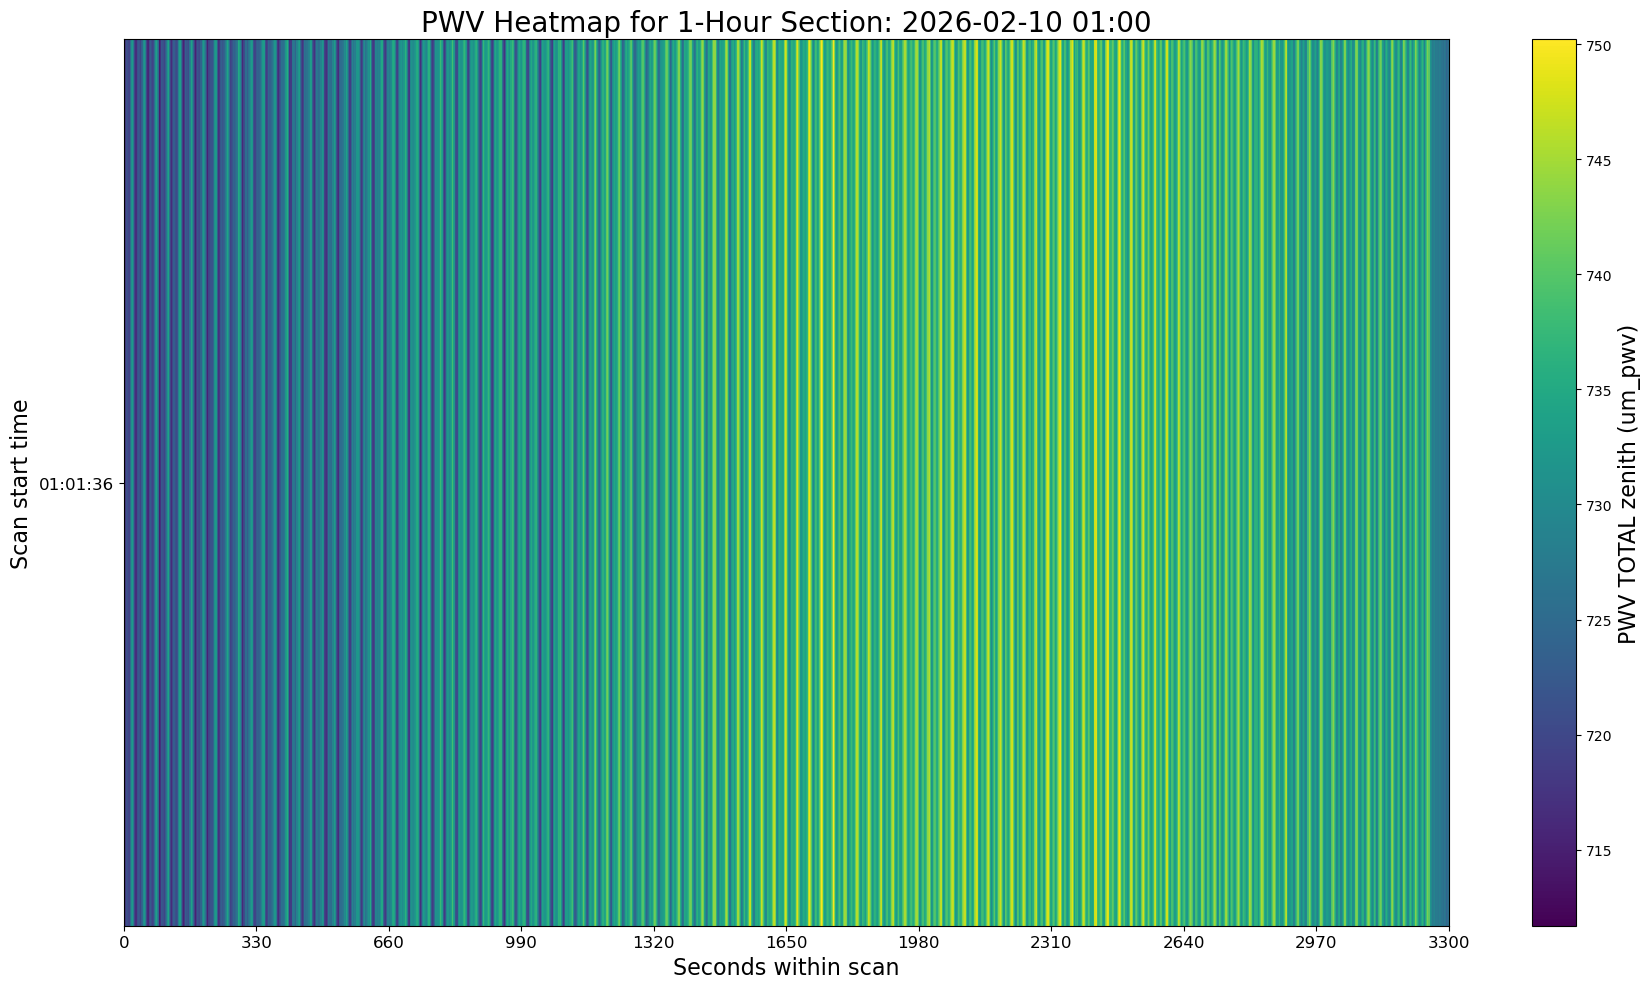

In [1]:
# gpt reviewed version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob

# -----------------------------
# 1. Read PWV files
# -----------------------------
files = sorted(glob.glob('2602/0210Sec/time_pwv_2602_*.csv'))

pwv_list = []

for file in files:
    df = pd.read_csv(
        file,
        dtype={
            'DATE(YYYYMMDD)': str,
            'START TIME(HHMMSS.Microsec)': str,
            'PWV TOTAL zenith': str,
            'PWV TOTAL line-of-sight': str
        }
    )

    df['TIME'] = pd.to_datetime(
        df['DATE(YYYYMMDD)'] + ' ' + df['START TIME(HHMMSS.Microsec)'],
        format='%Y%m%d %H%M%S.%f',
        errors='coerce'
    )

    df['PWV TOTAL zenith'] = pd.to_numeric(
        df['PWV TOTAL zenith'].str.replace(' um_pwv', '', regex=False),
        errors='coerce'
    )

    df['PWV TOTAL line-of-sight'] = pd.to_numeric(
        df['PWV TOTAL line-of-sight'].str.replace(' um_pwv', '', regex=False),
        errors='coerce'
    )

    df = df[['TIME', 'PWV TOTAL zenith', 'PWV TOTAL line-of-sight']].dropna()
    pwv_list.append(df)

pwv_df = pd.concat(pwv_list, ignore_index=True)
pwv_df = pwv_df.sort_values('TIME').drop_duplicates(subset='TIME')

# -----------------------------
# 2. Read AZ file
# -----------------------------
showAngle_df = pd.read_csv('2602/showAngle2602.csv')
showAngle_df['Time'] = pd.to_datetime(showAngle_df['Time'], errors='coerce')
showAngle_df = showAngle_df[['Time', 'AZ']].dropna().sort_values('Time')

# -----------------------------
# 3. Match PWV and AZ by nearest time
#    (better than exact equality)
# -----------------------------
merged = pd.merge_asof(
    pwv_df.sort_values('TIME'),
    showAngle_df.sort_values('Time'),
    left_on='TIME',
    right_on='Time',
    direction='nearest',
    tolerance=pd.Timedelta('1s')   # adjust if needed
)

merged = merged.dropna(subset=['AZ']).copy()

print(f"Matched rows: {len(merged)}")

# -----------------------------
# 4. Select one-hour section
#    Change this if you want a specific hour
# -----------------------------
hour_start = merged['TIME'].iloc[0].floor('h')
hour_end = hour_start + pd.Timedelta(hours=1)

one_hour = merged[(merged['TIME'] >= hour_start) & (merged['TIME'] < hour_end)].copy()

print(f"Rows in selected hour: {len(one_hour)}")
print(f"Hour section: {hour_start} to {hour_end}")

# -----------------------------
# 5. Define scan number
#    New scan when AZ drops
# -----------------------------
one_hour['scan_id'] = (one_hour['AZ'].diff().fillna(0) < 0).cumsum()

# Seconds from the start of each scan
one_hour['sec_in_scan'] = one_hour.groupby('scan_id')['TIME'].transform(
    lambda s: (s - s.iloc[0]).dt.total_seconds()
)

# Round to nearest second so we can pivot into a 2D grid
one_hour['sec_bin'] = one_hour['sec_in_scan'].round().astype(int)

# -----------------------------
# 6. Make 2D grid for heatmap
#    y = scan_id
#    x = seconds in scan
#    color = PWV zenith
# -----------------------------
heatmap = one_hour.pivot_table(
    index='scan_id',
    columns='sec_bin',
    values='PWV TOTAL zenith',
    aggfunc='mean'
)

heatmap = heatmap.sort_index().sort_index(axis=1)

# Optional: scan start-time labels
scan_labels = one_hour.groupby('scan_id')['TIME'].first().dt.strftime('%H:%M:%S')
scan_labels = scan_labels.reindex(heatmap.index)

# Mask NaNs so missing pixels do not look like low PWV
heatmap_masked = np.ma.masked_invalid(heatmap.values)

# -----------------------------
# 7. Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(18, 10))

im = ax.imshow(
    heatmap_masked,
    aspect='auto',
    origin='lower',
    cmap='viridis',
    interpolation='none'
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('PWV TOTAL zenith (um_pwv)', fontsize=16)

ax.set_title(f'PWV Heatmap for 1-Hour Section: {hour_start:%Y-%m-%d %H:%M}', fontsize=20)
ax.set_xlabel('Seconds within scan', fontsize=16)
ax.set_ylabel('Scan start time', fontsize=16)

# x ticks in seconds
x_positions = np.arange(len(heatmap.columns))
x_values = heatmap.columns.to_numpy()

# show about 10 x ticks
if len(x_positions) > 10:
    step = max(1, len(x_positions) // 10)
    ax.set_xticks(x_positions[::step])
    ax.set_xticklabels(x_values[::step], fontsize=12)
else:
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_values, fontsize=12)

# y ticks = scan start times
y_positions = np.arange(len(heatmap.index))
ax.set_yticks(y_positions)
ax.set_yticklabels(scan_labels, fontsize=12)

plt.tight_layout()
plt.show()

Matched rows: 61881
Rows in one hour: 3438
Time range: 2026-02-10 01:00:00 to 2026-02-10 02:00:00
                           TIME  PWV TOTAL zenith  PWV TOTAL line-of-sight  \
0    2026-02-10 01:01:36.217888           711.699                  868.824   
1    2026-02-10 01:01:37.278200           715.296                  873.215   
2    2026-02-10 01:01:38.237630           717.015                  875.313   
3    2026-02-10 01:01:39.196451           717.658                  876.099   
4    2026-02-10 01:01:40.158276           719.513                  878.363   
...                         ...               ...                      ...   
3433 2026-02-10 01:56:32.041734           725.544                  885.726   
3434 2026-02-10 01:56:33.000701           726.146                  886.461   
3435 2026-02-10 01:56:33.960835           725.419                  885.573   
3436 2026-02-10 01:56:34.921862           726.493                  886.885   
3437 2026-02-10 01:56:35.880915           72

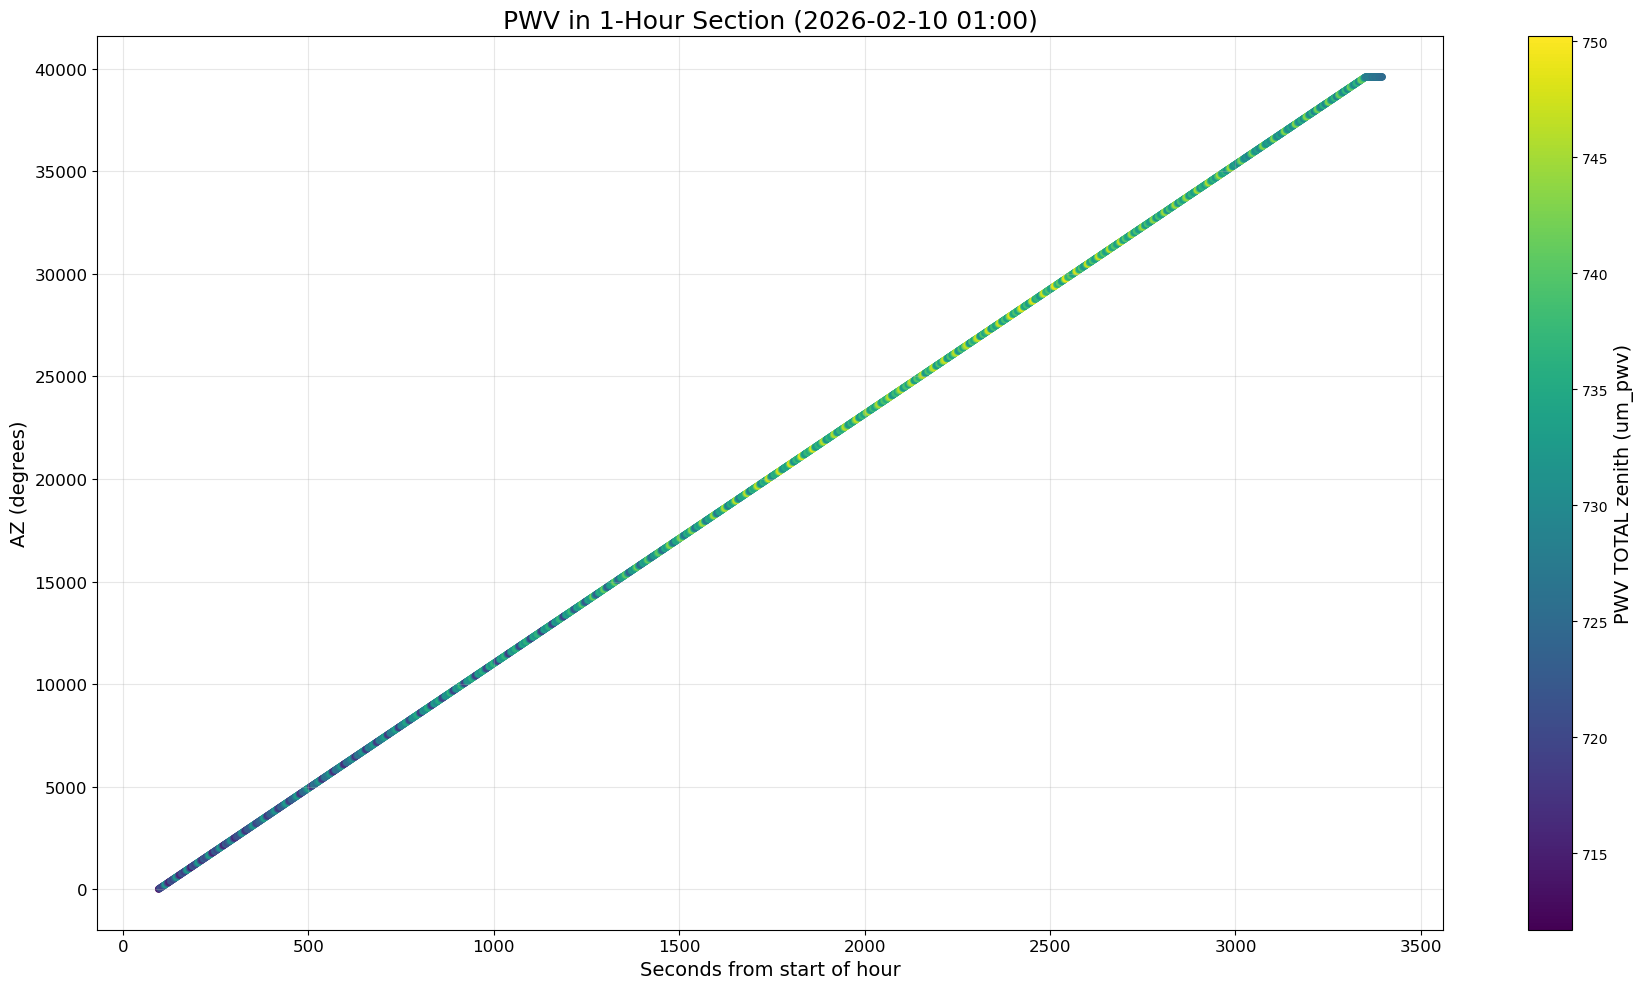

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob

# -----------------------------
# 1. Read PWV files
# -----------------------------
files = sorted(glob.glob('2602/0210Sec/time_pwv_2602_*.csv'))

pwv_list = []

for file in files:
    df = pd.read_csv(
        file,
        dtype={
            'DATE(YYYYMMDD)': str,
            'START TIME(HHMMSS.Microsec)': str,
            'PWV TOTAL zenith': str,
            'PWV TOTAL line-of-sight': str
        }
    )

    df['TIME'] = pd.to_datetime(
        df['DATE(YYYYMMDD)'] + ' ' + df['START TIME(HHMMSS.Microsec)'],
        format='%Y%m%d %H%M%S.%f',
        errors='coerce'
    )

    df['PWV TOTAL zenith'] = pd.to_numeric(
        df['PWV TOTAL zenith'].str.replace(' um_pwv', '', regex=False),
        errors='coerce'
    )

    df['PWV TOTAL line-of-sight'] = pd.to_numeric(
        df['PWV TOTAL line-of-sight'].str.replace(' um_pwv', '', regex=False),
        errors='coerce'
    )

    df = df[['TIME', 'PWV TOTAL zenith', 'PWV TOTAL line-of-sight']].dropna()
    pwv_list.append(df)

pwv_df = pd.concat(pwv_list, ignore_index=True)
pwv_df = pwv_df.sort_values('TIME').drop_duplicates(subset='TIME')

# -----------------------------
# 2. Read AZ file
# -----------------------------
showAngle_df = pd.read_csv('2602/showAngle2602.csv')
showAngle_df['Time'] = pd.to_datetime(showAngle_df['Time'], errors='coerce')
showAngle_df = showAngle_df[['Time', 'AZ']].dropna().sort_values('Time')

# -----------------------------
# 3. Match PWV to AZ by nearest time
# -----------------------------
merged = pd.merge_asof(
    pwv_df.sort_values('TIME'),
    showAngle_df.sort_values('Time'),
    left_on='TIME',
    right_on='Time',
    direction='nearest',
    tolerance=pd.Timedelta('1s')   # can change to '500ms' or '2s'
)

merged = merged.dropna(subset=['AZ']).copy()

print("Matched rows:", len(merged))

# -----------------------------
# 4. Select one-hour section
# -----------------------------
hour_start = merged['TIME'].iloc[0].floor('h')
hour_end = hour_start + pd.Timedelta(hours=1)

one_hour = merged[(merged['TIME'] >= hour_start) & (merged['TIME'] < hour_end)].copy()

print("Rows in one hour:", len(one_hour))
print("Time range:", hour_start, "to", hour_end)

# -----------------------------
# 5. x-axis = seconds from start of the hour
# -----------------------------
one_hour['sec_from_hour_start'] = (one_hour['TIME'] - hour_start).dt.total_seconds()
print(one_hour)
# -----------------------------
# 6. Scatter plot
# -----------------------------
fig, ax = plt.subplots(figsize=(18, 10))

sc = ax.scatter(
    one_hour['sec_from_hour_start'],
    one_hour['AZ'],
    c=one_hour['PWV TOTAL zenith'],
    s=18,          # point size
    cmap='viridis'
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('PWV TOTAL zenith (um_pwv)', fontsize=14)

ax.set_title(f'PWV in 1-Hour Section ({hour_start:%Y-%m-%d %H:%M})', fontsize=18)
ax.set_xlabel('Seconds from start of hour', fontsize=14)
ax.set_ylabel('AZ (degrees)', fontsize=14)

ax.tick_params(axis='both', labelsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()